<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB
       Temperature     Humidity   Wind_Speed  Cloud_Cover     Pressure
count  2500.000000  2500.000000  2500.000000  2500.000000  2500.000000
mean     22.581725    64.347094     9.906255    49.658104  1014.312336
std       7.326996    19.954739     5.780316    29.123104    20.196433
min      10.001842    30.005071     0.009819     0.015038   980.014486
25%      16.359398    47.339815     4.761909    23.900016   996.938630
50%      22.536448    63.920797     9.908572    49.488284  1013.433035
75%    

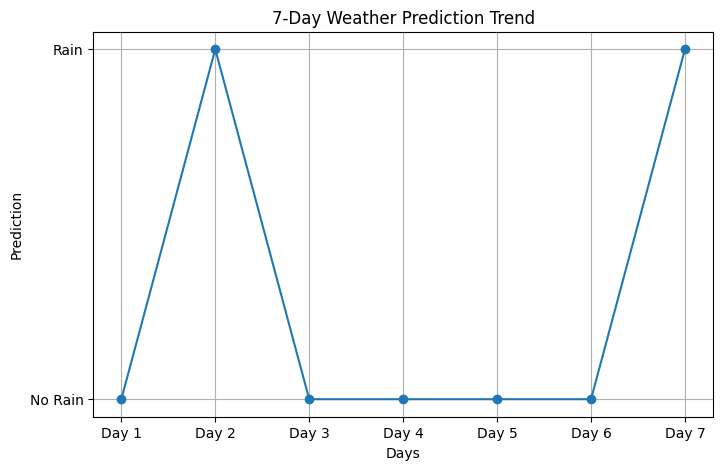

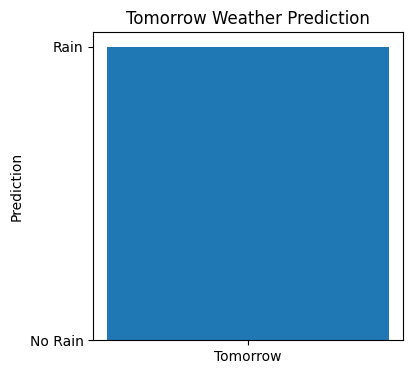

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/weather_forecast_data.csv')
df.info()
print(df.describe())
avg_humidity = df['Humidity'].mean()
avg_cloud = df['Cloud_Cover'].mean()

days = []
predictions = []

for i, row in enumerate(df.tail(7).itertuples(), start=1):

    humidity = row.Humidity
    cloud_cover = row.Cloud_Cover

    if humidity > avg_humidity and cloud_cover > avg_cloud:
        pred = "Rain"
        value = 1
    else:
        pred = "No Rain"
        value = 0

    days.append(f"Day {i}")
    predictions.append(value)
    tomorrow_humidity = df['Humidity'].iloc[-1]
tomorrow_cloud = df['Cloud_Cover'].iloc[-1]

print("\nTomorrow's Data")
print("Humidity:", tomorrow_humidity)
print("Cloud Cover:", tomorrow_cloud)

if tomorrow_humidity > avg_humidity and tomorrow_cloud > avg_cloud:
    print("\nTomorrow Prediction: Rain")
else:
    print("\nTomorrow Prediction: No Rain")

plt.figure(figsize=(8,5))
plt.plot(days, predictions, marker='o')

plt.title("7-Day Weather Prediction Trend")
plt.xlabel("Days")
plt.ylabel("Prediction")
plt.yticks([0,1], ["No Rain", "Rain"])

plt.grid(True)
plt.show()
prediction = 1 if (tomorrow_humidity > avg_humidity and tomorrow_cloud > avg_cloud) else 0

plt.figure(figsize=(4,4))
plt.bar(["Tomorrow"], [prediction])

plt.title("Tomorrow Weather Prediction")
plt.ylabel("Prediction")
plt.yticks([0,1], ["No Rain", "Rain"])

plt.show()